In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [4]:
df = pd.read_csv("disease_prediction_cleaned_eda.csv")

df.head()

,Patient_ID,Age,Gender,Symptoms,Blood_Pressure,Sugar_Level,Cholesterol,Medical_History,Disease,Age_Group
0,P100001,64,Female,"abdominal pain, nausea, vomiting",141,108,212,Unknown,Gastroenteritis,61-75
1,P100002,33,Male,"body ache, fever, fatigue",131,92,230,Seasonal flu,Flu,31-45
2,P100003,18,Male,Unknown,104,91,158,Unknown,Healthy,18-30
3,P100004,18,Female,"dizziness, nausea, sensitivity to light",112,85,206,Family history of migraine,Migraine,18-30
4,P100005,70,Male,"frequent urination, blurred vision, increased ...",157,188,184,Diabetes,Diabetes,61-75


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (3000, 10)

Columns:
['Patient_ID', 'Age', 'Gender', 'Symptoms', 'Blood_Pressure', 'Sugar_Level', 'Cholesterol', 'Medical_History', 'Disease', 'Age_Group']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Patient_ID       3000 non-null   object
 1   Age              3000 non-null   int64 
 2   Gender           3000 non-null   object
 3   Symptoms         3000 non-null   object
 4   Blood_Pressure   3000 non-null   int64 
 5   Sugar_Level      3000 non-null   int64 
 6   Cholesterol      3000 non-null   int64 
 7   Medical_History  3000 non-null   object
 8   Disease          3000 non-null   object
 9   Age_Group        3000 non-null   object
dtypes: int64(4), object(6)
memory usage: 234.5+ KB


In [7]:
df.isnull().sum()

Patient_ID         0
Age                0
Gender             0
Symptoms           0
Blood_Pressure     0
Sugar_Level        0
Cholesterol        0
Medical_History    0
Disease            0
Age_Group          0
dtype: int64

In [8]:
df = df.drop("Patient_ID", axis=1)


In [9]:
df.head()

,Age,Gender,Symptoms,Blood_Pressure,Sugar_Level,Cholesterol,Medical_History,Disease,Age_Group
0,64,Female,"abdominal pain, nausea, vomiting",141,108,212,Unknown,Gastroenteritis,61-75
1,33,Male,"body ache, fever, fatigue",131,92,230,Seasonal flu,Flu,31-45
2,18,Male,Unknown,104,91,158,Unknown,Healthy,18-30
3,18,Female,"dizziness, nausea, sensitivity to light",112,85,206,Family history of migraine,Migraine,18-30
4,70,Male,"frequent urination, blurred vision, increased ...",157,188,184,Diabetes,Diabetes,61-75


In [10]:
X = df.drop("Disease", axis=1)

y = df["Disease"]

In [11]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Age', 'Gender', 'Symptoms', 'Blood_Pressure', 'Sugar_Level', 'Cholesterol', 'Medical_History', 'Age_Group']

Target:
Disease


In [12]:
df["Symptoms"].head(10)

0                     abdominal pain, nausea, vomiting
1                            body ache, fever, fatigue
2                                              Unknown
3              dizziness, nausea, sensitivity to light
4    frequent urination, blurred vision, increased ...
5                                              Unknown
6                                  dizziness, headache
7              diarrhea, fever, abdominal pain, nausea
8                              fatigue, blurred vision
9                   fatigue, cough, sore throat, fever
Name: Symptoms, dtype: object

In [13]:
# Split the symptoms and create a list of individual symptoms
all_symptoms = set()

for symptoms in df["Symptoms"]:
    for symptom in symptoms.split(","):
        all_symptoms.add(symptom.strip())

print("Number of unique symptoms:", len(all_symptoms))
print("\nSymptoms:")
print(sorted(all_symptoms))

Number of unique symptoms: 18

Symptoms:
['Unknown', 'abdominal pain', 'blurred vision', 'body ache', 'chest pain', 'cough', 'diarrhea', 'dizziness', 'fatigue', 'fever', 'frequent urination', 'headache', 'increased thirst', 'nausea', 'sensitivity to light', 'shortness of breath', 'sore throat', 'vomiting']


In [14]:
for symptom in sorted(all_symptoms):
    df[symptom] = df["Symptoms"].apply(
        lambda x: 1 if symptom in [s.strip() for s in x.split(",")] else 0
    )

In [15]:
df = df.drop("Symptoms", axis=1)



In [16]:
df.columns

Index(['Age', 'Gender', 'Blood_Pressure', 'Sugar_Level', 'Cholesterol',
       'Medical_History', 'Disease', 'Age_Group', 'Unknown', 'abdominal pain',
       'blurred vision', 'body ache', 'chest pain', 'cough', 'diarrhea',
       'dizziness', 'fatigue', 'fever', 'frequent urination', 'headache',
       'increased thirst', 'nausea', 'sensitivity to light',
       'shortness of breath', 'sore throat', 'vomiting'],
      dtype='object')

In [17]:
print("Gender:")
print(df["Gender"].unique())

print("\nMedical History:")
print(df["Medical_History"].unique())

print("\nAge Group:")
print(df["Age_Group"].unique())

Gender:
['Female' 'Male']

Medical History:
['Unknown' 'Seasonal flu' 'Family history of migraine' 'Diabetes'
 'Previous gastrointestinal infection' 'High cholesterol' 'Asthma'
 'Hypertension' 'Gastritis' 'Family history of hypertension'
 'Heart disease' 'Family history of diabetes'
 'Family history of heart disease' 'Previous respiratory infection'
 'Migraine']

Age Group:
['61-75' '31-45' '18-30' '46-60' '76+']


In [18]:
categorical_columns = ["Gender", "Medical_History", "Age_Group"]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [19]:
df.head()

,Age,Blood_Pressure,Sugar_Level,Cholesterol,Disease,Unknown,abdominal pain,blurred vision,body ache,chest pain,...,Medical_History_Hypertension,Medical_History_Migraine,Medical_History_Previous gastrointestinal infection,Medical_History_Previous respiratory infection,Medical_History_Seasonal flu,Medical_History_Unknown,Age_Group_31-45,Age_Group_46-60,Age_Group_61-75,Age_Group_76+
0,64,141,108,212,Gastroenteritis,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1,33,131,92,230,Flu,0,0,0,1,0,...,0,0,0,0,1,0,1,0,0,0
2,18,104,91,158,Healthy,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,18,112,85,206,Migraine,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,70,157,188,184,Diabetes,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0


In [20]:
print(df.columns.tolist())

['Age', 'Blood_Pressure', 'Sugar_Level', 'Cholesterol', 'Disease', 'Unknown', 'abdominal pain', 'blurred vision', 'body ache', 'chest pain', 'cough', 'diarrhea', 'dizziness', 'fatigue', 'fever', 'frequent urination', 'headache', 'increased thirst', 'nausea', 'sensitivity to light', 'shortness of breath', 'sore throat', 'vomiting', 'Gender_Male', 'Medical_History_Diabetes', 'Medical_History_Family history of diabetes', 'Medical_History_Family history of heart disease', 'Medical_History_Family history of hypertension', 'Medical_History_Family history of migraine', 'Medical_History_Gastritis', 'Medical_History_Heart disease', 'Medical_History_High cholesterol', 'Medical_History_Hypertension', 'Medical_History_Migraine', 'Medical_History_Previous gastrointestinal infection', 'Medical_History_Previous respiratory infection', 'Medical_History_Seasonal flu', 'Medical_History_Unknown', 'Age_Group_31-45', 'Age_Group_46-60', 'Age_Group_61-75', 'Age_Group_76+']


In [21]:
label_encoder = LabelEncoder()

df["Disease"] = label_encoder.fit_transform(df["Disease"])

In [22]:
disease_mapping = dict(
    zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
)

print(disease_mapping)

{'Diabetes': np.int64(0), 'Flu': np.int64(1), 'Gastroenteritis': np.int64(2), 'Healthy': np.int64(3), 'Heart Disease': np.int64(4), 'Hypertension': np.int64(5), 'Migraine': np.int64(6), 'Pneumonia': np.int64(7)}


In [23]:
X = df.drop("Disease", axis=1)

y = df["Disease"]

In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 41)
y shape: (3000,)


In [25]:
print("Data types:")
print(X.dtypes.value_counts())

print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nTarget classes:")
print(y.nunique())

Data types:
int64    41
Name: count, dtype: int64

Missing values:
0

Target classes:
8


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)


Training data: (2400, 41)
Testing data: (600, 41)
Training target: (2400,)
Testing target: (600,)


In [29]:
scaler = StandardScaler()

numerical_columns = [
    "Age",
    "Blood_Pressure",
    "Sugar_Level",
    "Cholesterol"
]

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

In [30]:
X_train[numerical_columns].head()

,Age,Blood_Pressure,Sugar_Level,Cholesterol
2309,0.796477,-1.143800,-0.526869,-1.768019
409,1.805906,0.396880,-0.291786,0.091534
1117,0.922655,-0.453150,-0.497484,-0.274742
2630,-1.474740,-0.134389,1.265645,0.683209
722,0.354851,0.237499,2.264751,-0.021166


In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [34]:
logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
y_pred_lr = logistic_model.predict(X_test)

In [36]:
print(y_pred_lr[:10])

[5 5 5 0 1 5 5 0 5 1]


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [38]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1-Score :", f1_lr)

Logistic Regression Results
---------------------------
Accuracy : 0.99
Precision: 0.9901385148918809
Recall   : 0.99
F1-Score : 0.9900130509717119


In [39]:
print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.9900
Precision: 0.9901
Recall   : 0.9900
F1-Score : 0.9900


In [40]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=label_encoder.classes_,
    zero_division=0
))

                 precision    recall  f1-score   support

       Diabetes       0.99      0.99      0.99        91
            Flu       1.00      0.99      0.99       100
Gastroenteritis       1.00      0.98      0.99        50
        Healthy       0.97      1.00      0.98        92
  Heart Disease       1.00      1.00      1.00        67
   Hypertension       0.99      0.98      0.98        87
       Migraine       1.00      1.00      1.00        55
      Pneumonia       0.98      0.98      0.98        58

       accuracy                           0.99       600
      macro avg       0.99      0.99      0.99       600
   weighted avg       0.99      0.99      0.99       600



In [41]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

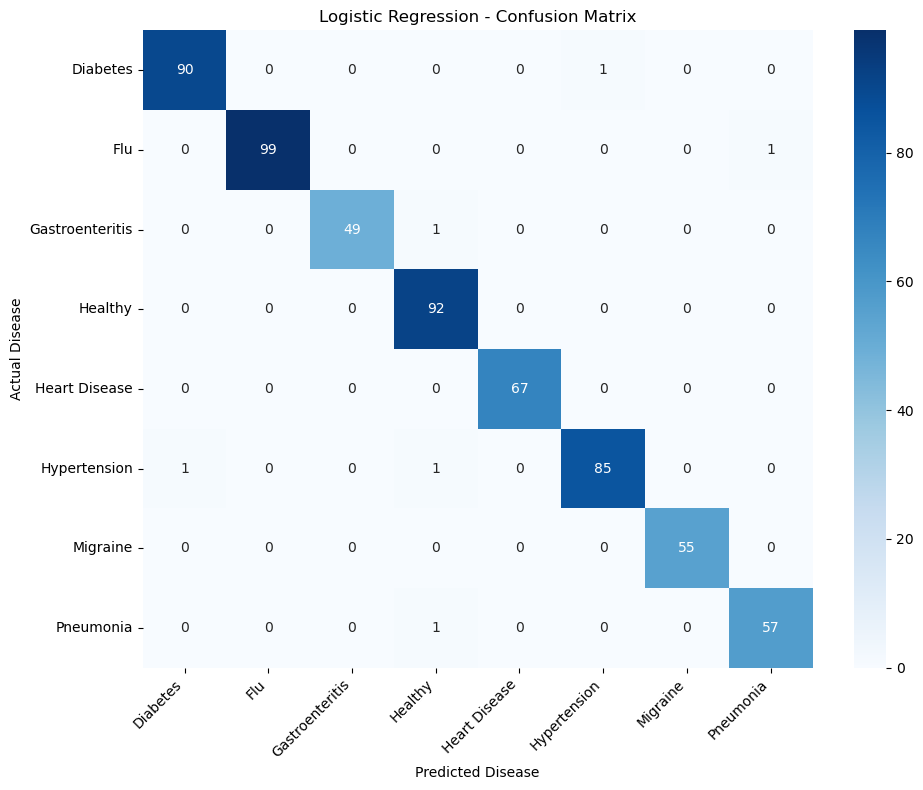

In [42]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("Logistic Regression - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

In [45]:
decision_tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
y_pred_dt = decision_tree_model.predict(X_test)

In [48]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

In [49]:
print("Decision Tree Results")
print("---------------------")
print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")

Decision Tree Results
---------------------
Accuracy : 0.9717
Precision: 0.9720
Recall   : 0.9717
F1-Score : 0.9717


In [50]:
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=label_encoder.classes_,
    zero_division=0
))

                 precision    recall  f1-score   support

       Diabetes       0.96      0.99      0.97        91
            Flu       0.97      0.97      0.97       100
Gastroenteritis       0.98      0.98      0.98        50
        Healthy       0.99      0.97      0.98        92
  Heart Disease       0.97      0.97      0.97        67
   Hypertension       1.00      0.97      0.98        87
       Migraine       0.95      0.98      0.96        55
      Pneumonia       0.95      0.95      0.95        58

       accuracy                           0.97       600
      macro avg       0.97      0.97      0.97       600
   weighted avg       0.97      0.97      0.97       600



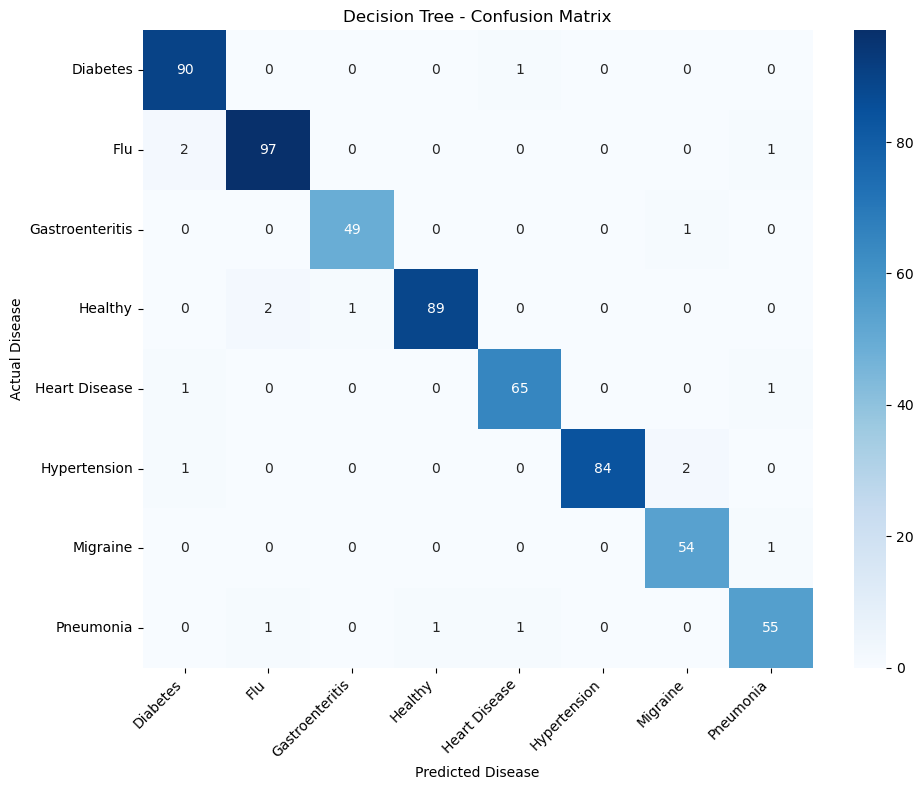

In [51]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("Decision Tree - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [54]:
random_forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
y_pred_rf = random_forest_model.predict(X_test)

In [56]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

In [57]:
print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

Random Forest Results
---------------------
Accuracy : 0.9867
Precision: 0.9868
Recall   : 0.9867
F1-Score : 0.9867


In [58]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_,
    zero_division=0
))

                 precision    recall  f1-score   support

       Diabetes       0.99      1.00      0.99        91
            Flu       0.98      0.98      0.98       100
Gastroenteritis       1.00      1.00      1.00        50
        Healthy       0.98      0.99      0.98        92
  Heart Disease       1.00      1.00      1.00        67
   Hypertension       1.00      0.98      0.99        87
       Migraine       1.00      0.98      0.99        55
      Pneumonia       0.95      0.97      0.96        58

       accuracy                           0.99       600
      macro avg       0.99      0.99      0.99       600
   weighted avg       0.99      0.99      0.99       600



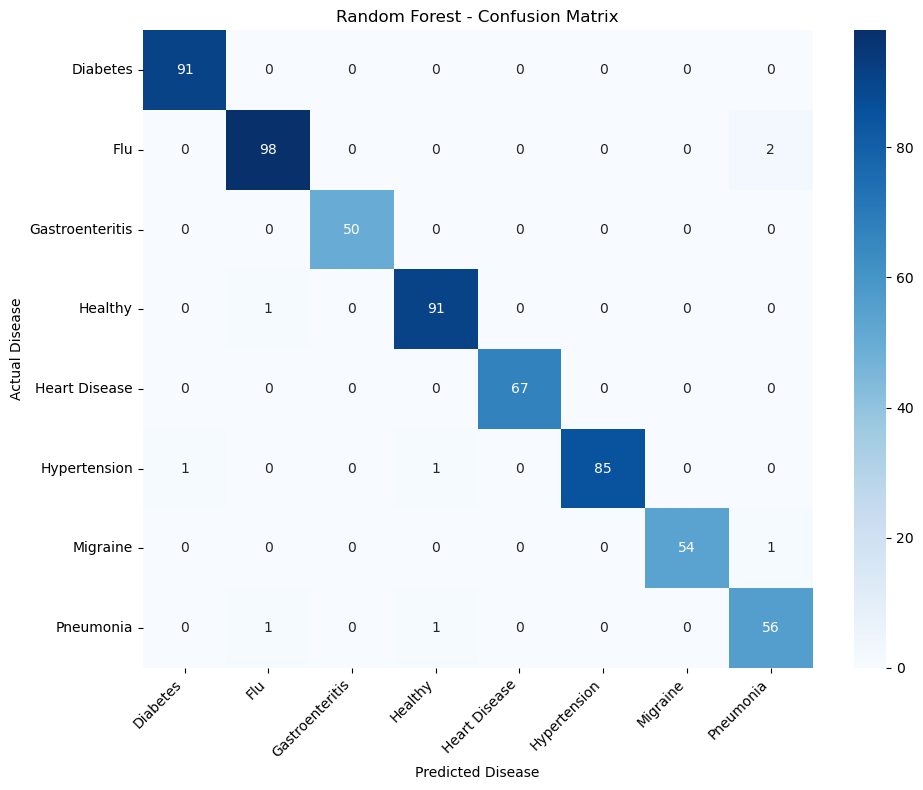

In [59]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("Random Forest - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [60]:
from sklearn.naive_bayes import GaussianNB

In [61]:
naive_bayes_model = GaussianNB()

In [62]:
naive_bayes_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [63]:
y_pred_nb = naive_bayes_model.predict(X_test)

In [64]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

In [65]:
print("Naive Bayes Results")
print("-------------------")
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1-Score : {f1_nb:.4f}")

Naive Bayes Results
-------------------
Accuracy : 0.9933
Precision: 0.9935
Recall   : 0.9933
F1-Score : 0.9934


In [66]:
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=label_encoder.classes_,
    zero_division=0
))

                 precision    recall  f1-score   support

       Diabetes       1.00      1.00      1.00        91
            Flu       1.00      0.98      0.99       100
Gastroenteritis       1.00      1.00      1.00        50
        Healthy       0.98      1.00      0.99        92
  Heart Disease       1.00      1.00      1.00        67
   Hypertension       1.00      0.99      0.99        87
       Migraine       1.00      1.00      1.00        55
      Pneumonia       0.97      0.98      0.97        58

       accuracy                           0.99       600
      macro avg       0.99      0.99      0.99       600
   weighted avg       0.99      0.99      0.99       600



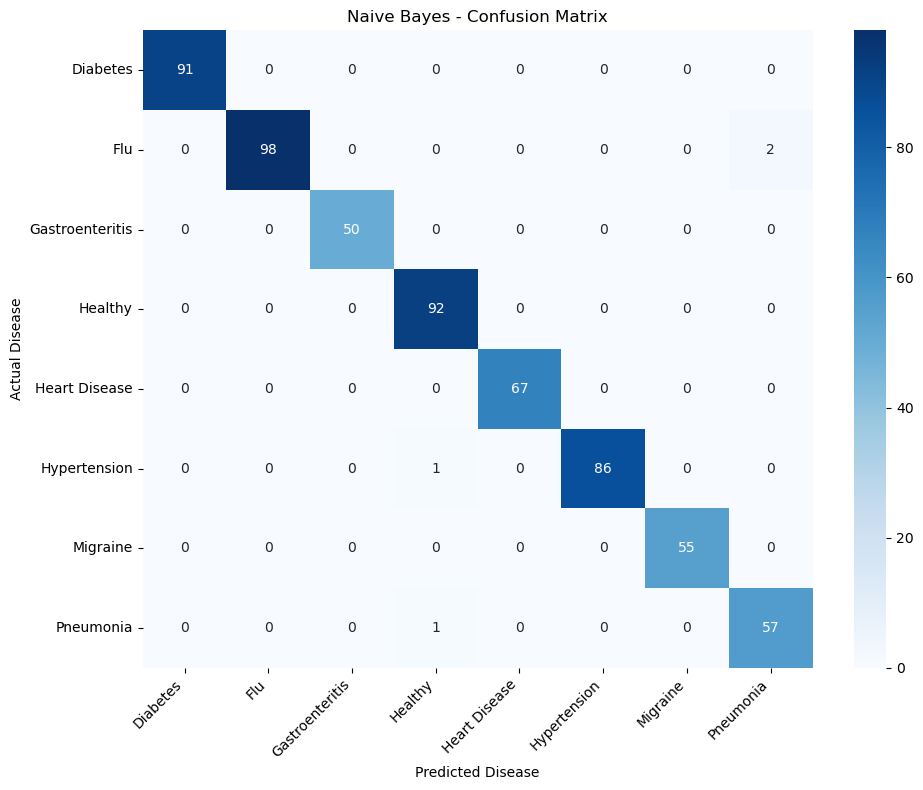

In [67]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("Naive Bayes - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [69]:
from sklearn.svm import SVC

In [70]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

In [71]:
svm_model.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [72]:
y_pred_svm = svm_model.predict(X_test)

In [73]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

In [74]:
print("SVM Results")
print("-----------")
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")

SVM Results
-----------
Accuracy : 0.9867
Precision: 0.9869
Recall   : 0.9867
F1-Score : 0.9867


In [75]:
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=label_encoder.classes_,
    zero_division=0
))

                 precision    recall  f1-score   support

       Diabetes       0.99      0.99      0.99        91
            Flu       0.99      0.99      0.99       100
Gastroenteritis       1.00      0.98      0.99        50
        Healthy       0.96      1.00      0.98        92
  Heart Disease       1.00      1.00      1.00        67
   Hypertension       0.99      0.98      0.98        87
       Migraine       1.00      0.98      0.99        55
      Pneumonia       0.98      0.97      0.97        58

       accuracy                           0.99       600
      macro avg       0.99      0.99      0.99       600
   weighted avg       0.99      0.99      0.99       600



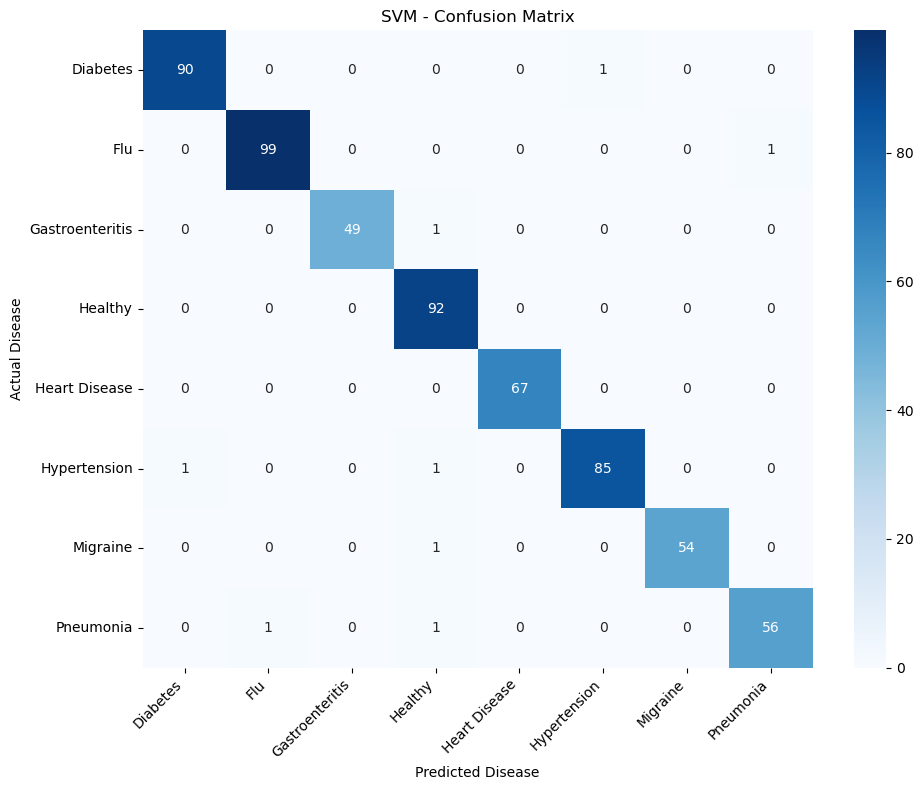

In [76]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("SVM - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_nb,
        accuracy_svm
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_nb,
        precision_svm
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_nb,
        recall_svm
    ],
    "F1-Score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_nb,
        f1_svm
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.990000,0.990139,0.990000,0.990013
1,Decision Tree,0.971667,0.972018,0.971667,0.971713
2,Random Forest,0.986667,0.986805,0.986667,0.986693
3,Naive Bayes,0.993333,0.993461,0.993333,0.993351
4,SVM,0.986667,0.986896,0.986667,0.986685


In [78]:
model_results[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
] = model_results[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].round(4)

model_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9900,0.9901,0.9900,0.9900
1,Decision Tree,0.9717,0.9720,0.9717,0.9717
2,Random Forest,0.9867,0.9868,0.9867,0.9867
3,Naive Bayes,0.9933,0.9935,0.9933,0.9934
4,SVM,0.9867,0.9869,0.9867,0.9867


In [79]:
model_results_sorted = model_results.sort_values(
    by="F1-Score",
    ascending=False
)

model_results_sorted

,Model,Accuracy,Precision,Recall,F1-Score
3,Naive Bayes,0.9933,0.9935,0.9933,0.9934
0,Logistic Regression,0.9900,0.9901,0.9900,0.9900
2,Random Forest,0.9867,0.9868,0.9867,0.9867
4,SVM,0.9867,0.9869,0.9867,0.9867
1,Decision Tree,0.9717,0.9720,0.9717,0.9717


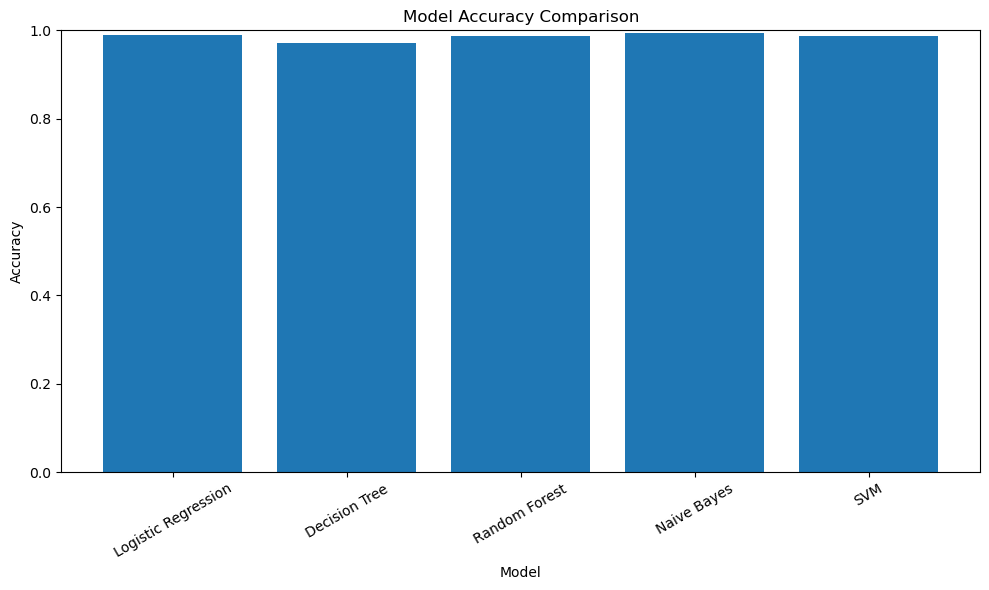

In [80]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

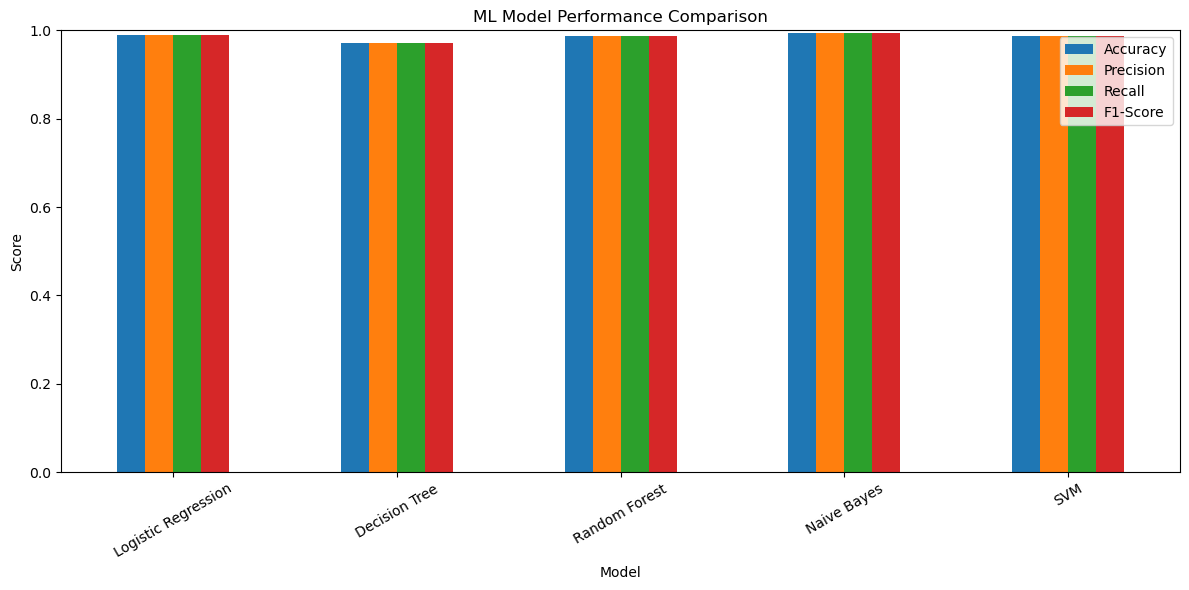

In [81]:
model_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

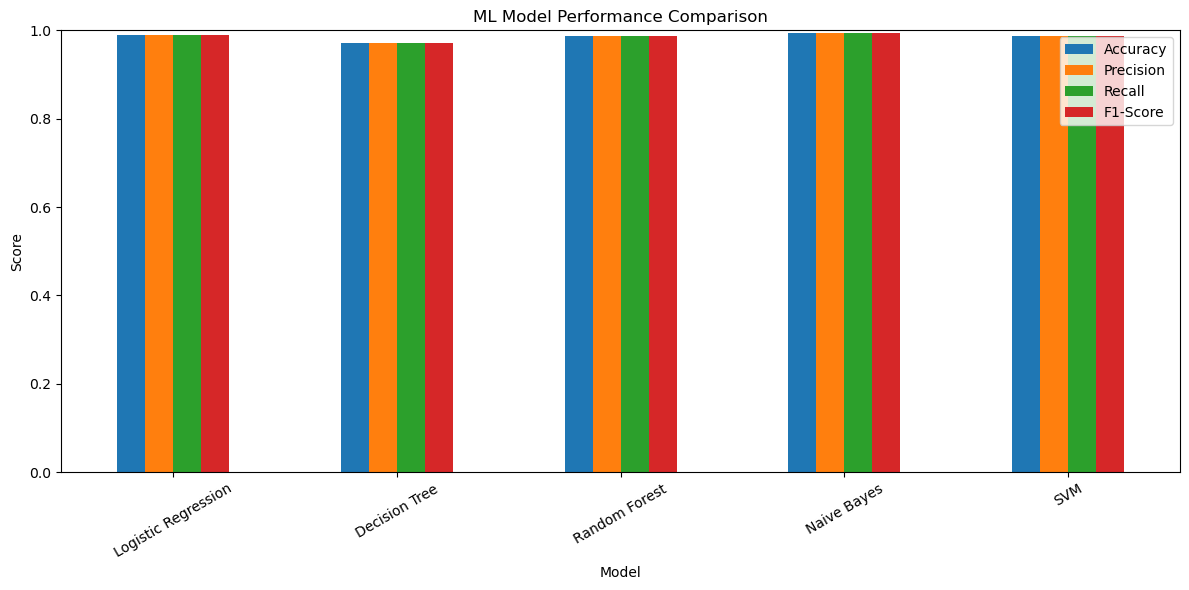

In [82]:
model_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("ML Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [83]:
best_model_name = model_results_sorted.iloc[0]["Model"]

best_f1_score = model_results_sorted.iloc[0]["F1-Score"]

print("Best Model:", best_model_name)
print("Best F1-Score:", best_f1_score)

Best Model: Naive Bayes
Best F1-Score: 0.9934


In [84]:
naive_bayes_model
y_test
y_pred_nb
label_encoder

LabelEncoder()

In [85]:
print("FINAL MODEL: NAIVE BAYES")
print("========================")

print(classification_report(
    y_test,
    y_pred_nb,
    target_names=label_encoder.classes_,
    zero_division=0
))

FINAL MODEL: NAIVE BAYES
                 precision    recall  f1-score   support

       Diabetes       1.00      1.00      1.00        91
            Flu       1.00      0.98      0.99       100
Gastroenteritis       1.00      1.00      1.00        50
        Healthy       0.98      1.00      0.99        92
  Heart Disease       1.00      1.00      1.00        67
   Hypertension       1.00      0.99      0.99        87
       Migraine       1.00      1.00      1.00        55
      Pneumonia       0.97      0.98      0.97        58

       accuracy                           0.99       600
      macro avg       0.99      0.99      0.99       600
   weighted avg       0.99      0.99      0.99       600



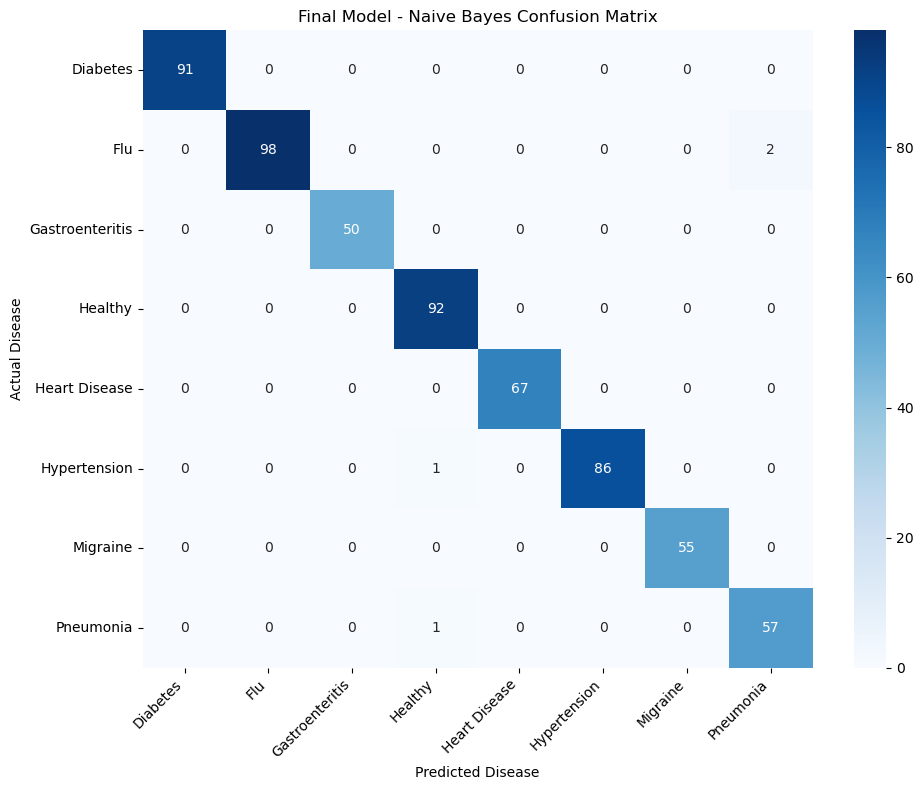

In [86]:
cm_final = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("Final Model - Naive Bayes Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [87]:
print("FINAL MODEL PERFORMANCE")
print("=======================")
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1-Score : {f1_nb:.4f}")

FINAL MODEL PERFORMANCE
Accuracy : 0.9933
Precision: 0.9935
Recall   : 0.9933
F1-Score : 0.9934


In [88]:
import joblib

joblib.dump(
    naive_bayes_model,
    "disease_prediction_naive_bayes.pkl"
)

print("Naive Bayes model saved successfully.")

Naive Bayes model saved successfully.


In [89]:
joblib.dump(
    label_encoder,
    "disease_label_encoder.pkl"
)

print("Label encoder saved successfully.")

Label encoder saved successfully.


In [90]:
joblib.dump(
    scaler,
    "disease_scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [91]:
feature_columns = X_train.columns.tolist()

joblib.dump(
    feature_columns,
    "disease_feature_columns.pkl"
)

print("Feature columns saved successfully.")
print("Number of features:", len(feature_columns))

Feature columns saved successfully.
Number of features: 41


In [92]:
joblib.dump(
    numerical_columns,
    "disease_numerical_columns.pkl"
)

print("Numerical columns saved successfully.")

Numerical columns saved successfully.


In [93]:
import os

files = [
    "disease_prediction_naive_bayes.pkl",
    "disease_label_encoder.pkl",
    "disease_scaler.pkl",
    "disease_feature_columns.pkl",
    "disease_numerical_columns.pkl"
]

for file in files:
    print(file, "→", "Exists" if os.path.exists(file) else "Missing")

disease_prediction_naive_bayes.pkl → Exists
disease_label_encoder.pkl → Exists
disease_scaler.pkl → Exists
disease_feature_columns.pkl → Exists
disease_numerical_columns.pkl → Exists


In [94]:
loaded_model = joblib.load(
    "disease_prediction_naive_bayes.pkl"
)

loaded_encoder = joblib.load(
    "disease_label_encoder.pkl"
)

loaded_features = joblib.load(
    "disease_feature_columns.pkl"
)

loaded_scaler = joblib.load(
    "disease_scaler.pkl"
)

print("All saved components loaded successfully.")

All saved components loaded successfully.


In [95]:
sample_patient = X_test.iloc[[0]]

sample_actual = y_test.iloc[0]

sample_prediction = loaded_model.predict(sample_patient)[0]

actual_disease = loaded_encoder.inverse_transform(
    [sample_actual]
)[0]

predicted_disease = loaded_encoder.inverse_transform(
    [sample_prediction]
)[0]

print("Actual Disease   :", actual_disease)
print("Predicted Disease:", predicted_disease)

Actual Disease   : Hypertension
Predicted Disease: Hypertension


In [96]:
probabilities = loaded_model.predict_proba(sample_patient)[0]

max_probability = probabilities.max()

print("Predicted Disease :", predicted_disease)
print("Model Probability :", f"{max_probability:.2%}")

Predicted Disease : Hypertension
Model Probability : 100.00%
